## Imports e configurações

In [1]:
# !pip install transformers[torch] torch torchmetrics pandas numpy scikit-learn pyarrow

In [2]:
USE_COLAB = False
USE_DRIVE = False

if USE_COLAB and USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")

In [3]:
import warnings
warnings.filterwarnings("ignore")

import re
import json
import time
import math
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Optimizer

from transformers import AutoTokenizer, AutoModel, get_scheduler

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, hamming_loss
)

# ─── Configurações globais ───────────────────────────────────────
RANDOM_STATE = 42

if USE_COLAB and USE_DRIVE:
    _DRIVE_ROOT = Path("/content/drive/MyDrive/Fuzzy_BERT")  # ← ajuste o nome da pasta
    DATA_DIR = _DRIVE_ROOT / "data/treated"
    OUT_DIR  = _DRIVE_ROOT / "data/out/bertimbau"
    CKPT_DIR = _DRIVE_ROOT / "data/checkpoints/bertimbau"
else:
    DATA_DIR = Path("../data/treated")
    OUT_DIR  = Path("../data/out/bertimbau")
    CKPT_DIR = Path("../data/checkpoints/bertimbau")

N_OUTER_FOLDS = 5
MODEL_NAME = "neuralmind/bert-base-portuguese-cased" # BERTimbau-base
TEXT_COL = "CLEAN_TEXT"
MAX_LEN = 128
BATCH_SIZE = 32
NUM_EPOCHS = 4
WARMUP_RATIO = 0.1 # 10% dos steps para warmup linear
LEARNING_RATE = 2e-5
THRESHOLD = 0.5 # limiar para binarizar probabilidades

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EMOTION_COLS = [
    'admiration', 'amusement', 'anger', 'annoyance',
    'approval', 'caring', 'confusion', 'curiosity', 'desire',
    'disappointment', 'disapproval', 'disgust', 'embarrassment',
    'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
    'nervousness', 'optimism', 'pride', 'realization', 'relief',
    'remorse', 'sadness', 'surprise', 'neutral'
]
N_LABELS = len(EMOTION_COLS)

OUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print(f"Device: {DEVICE}")
print(f"Modelo: {MODEL_NAME}")
print(f"Labels: {N_LABELS}")
print(f"Epochs: {NUM_EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Max length: {MAX_LEN}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Checkpoints em: {CKPT_DIR.resolve()}")

Device: cuda
Modelo: neuralmind/bert-base-portuguese-cased
Labels: 28
Epochs: 4
Batch size: 32
Max length: 128
Learning rate: 2e-05
Checkpoints em: C:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\data\checkpoints\bertimbau


## Carregamento dos folds

In [7]:
def load_fold(fold_id: int):
    """
    Carrega data.parquet e idx.npy de um fold.
    Retorna (df, idx_array).
    """
    fold_dir = DATA_DIR / f"fold_{fold_id}"
    df  = pd.read_parquet(fold_dir / "data.parquet")
    idx = np.load(fold_dir / "idx.npy")
    return df, idx

# Verifica disponibilidade dos folds
folds_data = {}
for k in range(1, N_OUTER_FOLDS + 1):
    df_k, idx_k = load_fold(k)
    folds_data[k] = {"df": df_k, "idx": idx_k}
    print(f"Fold {k}: {df_k.shape[0]:>6} amostras | idx shape: {idx_k.shape}")

# Inspeciona colunas do primeiro fold
print("\nColunas disponíveis:", folds_data[1]["df"].columns.tolist())

Fold 1:  10831 amostras | idx shape: (10831,)
Fold 2:  10810 amostras | idx shape: (10810,)
Fold 3:  10836 amostras | idx shape: (10836,)
Fold 4:  10909 amostras | idx shape: (10909,)
Fold 5:  10848 amostras | idx shape: (10848,)

Colunas disponíveis: ['id', 'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral', 'text', 'texto', 'UNCLEAN_TEXT', 'CLEAN_TEXT', 'letter_count', 'sentence_count', 'avg_letter_per_word', 'words_per_sentence', 'avg_syllables_per_word', 'reading_time', 'punctuation_per_word', 'exclamation_per_word', 'question_per_word', 'mean_verbs_per_word', 'mean_auxiliaries_per_word', 'mean_auxiliaries_per_sentence', 'flesch_portuguese', 'uppercase_percentage', 'mean_unique_word_length', 'mean_char_rep

## Dataset e DataLoader

In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class EmotionDataset(Dataset):
    """Dataset PyTorch para classificação multi-label de emoções."""

    def __init__(self, df: pd.DataFrame, tokenizer, max_len: int = MAX_LEN):
        self.texts = df[TEXT_COL].fillna("").astype(str).tolist()
        present = [c for c in EMOTION_COLS if c in df.columns]
        self.labels = df[present].values.astype(np.float32)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length = self.max_len,
            padding = "max_length",
            truncation = True,
            return_tensors = "pt",
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.float32),
        }


def make_loaders(df_train, df_test):
    ds_train = EmotionDataset(df_train, tokenizer)
    ds_test  = EmotionDataset(df_test,  tokenizer)
    
    loader_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=0,
                              pin_memory=True)
    loader_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=0,
                              pin_memory=True)
    return loader_train, loader_test

print("Tokenizer carregado:", MODEL_NAME)

Tokenizer carregado: neuralmind/bert-base-portuguese-cased


## Modelo — BERTimbau + cabeça de classificação multi-label

In [9]:
class BERTimbauForEmotions(nn.Module):
    """
    BERTimbau-base com cabeça linear multi-label.
    Usa o [CLS] token como representação da sequência.
    """

    def __init__(self, model_name: str = MODEL_NAME, n_labels: int = N_LABELS,
                 dropout: float = 0.1):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, n_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]   # [CLS]
        cls_output = self.dropout(cls_output)
        logits = self.classifier(cls_output)          # (B, N_LABELS)
        return logits

## Cross Balanced Loss (CB Loss)

Implementação da **Class-Balanced Loss** baseada em:
> Cui et al. (2019). *Class-Balanced Loss Based on Effective Number of Samples*. CVPR.

$$\text{CB}(p, y) = \frac{1 - \beta}{1 - \beta^{n_y}} \cdot \ell(p, y)$$

onde $n_y$ é o número de amostras da classe $y$ e $\beta = (N-1)/N$.

In [10]:
class CrossBalancedLoss(nn.Module):
    """
    Class-Balanced Binary Cross-Entropy para classificação multi-label.

    Parâmetros
    ----------
    samples_per_class : array-like (N_LABELS,)
        Número de amostras positivas por label no conjunto de treino.
    beta : float
        Hiperparâmetro de suavização (padrão 0.9999, original do paper).
        Valores comuns: 0.9, 0.99, 0.999, 0.9999.
    """

    def __init__(self, samples_per_class: np.ndarray, beta: float = 0.9999):
        super().__init__()

        # Número efetivo de amostras: EN = (1 - beta^n) / (1 - beta)
        effective_num = 1.0 - np.power(beta, samples_per_class)
        # Peso inversamente proporcional ao número efetivo
        weights = (1.0 - beta) / np.where(effective_num == 0, 1e-8, effective_num)
        # Normaliza para que a soma dos pesos = N_LABELS
        weights = weights / weights.sum() * len(samples_per_class)

        self.register_buffer(
            "weights",
            torch.tensor(weights, dtype=torch.float32)
        )

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        logits  : (B, N_LABELS) — logits brutos do modelo
        targets : (B, N_LABELS) — rótulos binários {0, 1}
        """
        # BCE por elemento, sem redução
        bce = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, reduction="none"
        )   # (B, N_LABELS)

        # Aplica os pesos de balanceamento por label
        weighted_bce = bce * self.weights.unsqueeze(0)  # broadcast em batch

        return weighted_bce.mean()

def compute_samples_per_class(df: pd.DataFrame) -> np.ndarray:
    """Conta positivos por label. Labels ausentes recebem 1 (evita divisão por zero)."""
    counts = np.array([
        int(df[c].sum()) if c in df.columns else 1
        for c in EMOTION_COLS
    ], dtype=np.float64)
    return np.maximum(counts, 1)   # garante >= 1

## AdamWeightDecayOptimizer

Reimplementação fiel ao código original do BERT (Devlin et al.), portada para PyTorch.

Exclui LayerNorm e bias do weight decay, conforme recomendado.

In [11]:
class AdamWeightDecayOptimizer(Optimizer):
    """
    Adam com L2 weight decay correto (desacoplado do momentum).
    Porta PyTorch do otimizador original do BERT (TF1).

    Parâmetros
    ----------
    params                  : parâmetros do modelo
    lr                      : learning rate inicial
    weight_decay_rate       : taxa de L2 weight decay
    beta_1, beta_2, epsilon : hiperparâmetros Adam
    exclude_from_weight_decay : lista de substrings de nomes de parâmetros
                                que NÃO devem ter weight decay
    """

    def __init__(
        self,
        params,
        lr: float = 2e-5,
        weight_decay_rate: float = 0.01,
        beta_1: float = 0.9,
        beta_2: float = 0.999,
        epsilon: float = 1e-6,
        exclude_from_weight_decay=None,
    ):
        if exclude_from_weight_decay is None:
            exclude_from_weight_decay = ["LayerNorm", "layer_norm", "bias"]

        defaults = dict(
            lr=lr,
            weight_decay_rate=weight_decay_rate,
            beta_1=beta_1,
            beta_2=beta_2,
            epsilon=epsilon,
            exclude_from_weight_decay=exclude_from_weight_decay,
        )
        super().__init__(params, defaults)

    def _do_use_weight_decay(self, param_name: str, exclude_list) -> bool:
        """Retorna True se weight decay deve ser aplicado a este parâmetro."""
        for pattern in exclude_list:
            if re.search(pattern, param_name) is not None:
                return False
        return True

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            beta_1 = group["beta_1"]
            beta_2 = group["beta_2"]
            epsilon = group["epsilon"]
            wd_rate = group["weight_decay_rate"]
            lr = group["lr"]
            exclude = group["exclude_from_weight_decay"]

            for p in group["params"]:
                if p.grad is None:
                    continue

                grad = p.grad.data
                state = self.state[p]

                # Inicializa estado
                if len(state) == 0:
                    state["m"] = torch.zeros_like(p.data)
                    state["v"] = torch.zeros_like(p.data)
                    # Guarda o nome do parâmetro para decisão de weight decay
                    # (PyTorch não passa o nome diretamente; usamos o id)
                    state["step"] = 0

                m, v = state["m"], state["v"]
                state["step"] += 1

                # Atualização Adam padrão
                next_m = beta_1 * m + (1.0 - beta_1) * grad
                next_v = beta_2 * v + (1.0 - beta_2) * grad.pow(2)

                update = next_m / (next_v.sqrt() + epsilon)

                # Weight decay desacoplado (não interage com m/v)
                # Recupera nome do parâmetro via param_names mapeado no grupo
                param_name = group.get("_param_names", {}).get(id(p), "")
                if wd_rate > 0 and self._do_use_weight_decay(param_name, exclude):
                    update = update + wd_rate * p.data

                p.data.add_(update, alpha=-lr)

                state["m"].copy_(next_m)
                state["v"].copy_(next_v)

        return loss

def build_optimizer(model: nn.Module, lr: float = LEARNING_RATE) -> AdamWeightDecayOptimizer:
    """
    Constrói o AdamWeightDecayOptimizer com mapeamento nome → id de parâmetro,
    necessário para a exclusão correta de LayerNorm e bias do weight decay.
    """
    # Separa parâmetros: com e sem weight decay
    exclude_patterns = ["LayerNorm", "layer_norm", "bias"]

    decay_params = []
    no_decay_params = []
    param_names_map = {}   # id(param) -> nome

    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        param_names_map[id(param)] = name
        if any(re.search(pat, name) for pat in exclude_patterns):
            no_decay_params.append(param)
        else:
            decay_params.append(param)

    param_groups = [
        {"params": decay_params, "weight_decay_rate": 0.01},
        {"params": no_decay_params, "weight_decay_rate": 0.0},
    ]

    optimizer = AdamWeightDecayOptimizer(
        param_groups,
        lr=lr,
        weight_decay_rate=0.01,
        beta_1=0.9,
        beta_2=0.999,
        epsilon=1e-6,
        exclude_from_weight_decay=exclude_patterns,
    )

    # Injeta o mapeamento nome→param em todos os grupos para uso no step()
    for g in optimizer.param_groups:
        g["_param_names"] = param_names_map

    return optimizer

def build_polynomial_scheduler(optimizer, num_train_steps: int, warmup_ratio: float = WARMUP_RATIO):
    """
    Polynomial decay com warmup linear.
    Espelha o comportamento do tf.train.polynomial_decay do código original.

    Fase 1 (warmup): lr cresce linearmente de 0 até lr_inicial
    Fase 2 (decay) : lr decai polinomialmente (power=1.0) até 0
    """
    num_warmup_steps = int(num_train_steps * warmup_ratio)

    def lr_lambda(current_step: int):
        # Warmup linear
        if current_step < num_warmup_steps:
            return float(current_step) / float(max(1, num_warmup_steps))
        # Polynomial decay (power=1 → linear)
        progress = float(current_step - num_warmup_steps) / float(
            max(1, num_train_steps - num_warmup_steps)
        )
        return max(0.0, 1.0 - progress)   # power=1.0, end_lr=0.0

    from torch.optim.lr_scheduler import LambdaLR
    return LambdaLR(optimizer, lr_lambda)

## Funções de treino, avaliação e checkpoint

In [12]:
def save_checkpoint(model, optimizer, scheduler, epoch, fold, metrics, ckpt_dir: Path):
    """
    Salva um checkpoint ao final de cada época.
    Arquivo: ckpt_dir/fold_{fold}_epoch_{epoch}.pt
    """
    ckpt_path = ckpt_dir / f"fold_{fold}_epoch_{epoch:02d}.pt"
    torch.save({
        "epoch": epoch,
        "fold": fold,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "metrics": metrics,
    }, ckpt_path)
    print(f"✓ Checkpoint salvo: {ckpt_path.name}")
    return ckpt_path

def load_checkpoint(ckpt_path: Path, model, optimizer=None, scheduler=None):
    import numpy.dtypes
    torch.serialization.add_safe_globals([
        numpy.dtypes.Float64DType,
    ])
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    if optimizer is not None:
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    if scheduler is not None:
        scheduler.load_state_dict(ckpt["scheduler_state_dict"])
    print(f"Checkpoint carregado: fold={ckpt['fold']}, epoch={ckpt['epoch']}")
    return ckpt

def train_one_epoch(model, loader, optimizer, scheduler, criterion, device):
    """Treina o modelo por uma época. Retorna loss médio."""
    model.train()
    total_loss = 0.0

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(logits, labels)

        loss.backward()

        # Gradient clipping (recomendado para fine-tuning BERT)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    return total_loss / len(loader)

@torch.no_grad()
def evaluate(model, loader, criterion, device, threshold: float = THRESHOLD):
    """Avalia o modelo. Retorna loss, Y_true, Y_pred, Y_proba."""
    model.eval()
    total_loss = 0.0
    all_logits = []
    all_labels = []

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(logits, labels)

        total_loss += loss.item()
        all_logits.append(logits.cpu())
        all_labels.append(labels.cpu())

    all_logits = torch.cat(all_logits, dim=0)   # (N, N_LABELS)
    all_labels = torch.cat(all_labels, dim=0)

    Y_proba = torch.sigmoid(all_logits).numpy()
    Y_pred = (Y_proba >= threshold).astype(int)
    Y_true = all_labels.numpy().astype(int)

    avg_loss = total_loss / len(loader)
    return avg_loss, Y_true, Y_pred, Y_proba

def compute_metrics(Y_true, Y_pred, Y_proba, label_names):
    """Calcula métricas multi-label idênticas ao baseline."""
    metrics = {
        "accuracy": accuracy_score(Y_true, Y_pred),
        "hamming_loss": hamming_loss(Y_true, Y_pred),
        "f1_macro": f1_score(Y_true, Y_pred, average="macro",    zero_division=0),
        "f1_micro": f1_score(Y_true, Y_pred, average="micro",    zero_division=0),
        "f1_weighted": f1_score(Y_true, Y_pred, average="weighted", zero_division=0),
        "precision_macro": precision_score(Y_true, Y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(Y_true, Y_pred, average="macro",    zero_division=0),
    }

    valid_cols = [j for j in range(Y_true.shape[1]) if Y_true[:, j].sum() > 0]
    if valid_cols:
        metrics["roc_auc_macro"] = roc_auc_score(
            Y_true[:, valid_cols], Y_proba[:, valid_cols], average="macro"
        )
    else:
        metrics["roc_auc_macro"] = float("nan")

    f1_per = f1_score(Y_true, Y_pred, average=None, zero_division=0)
    metrics["f1_per_label"] = dict(zip(label_names, f1_per))

    return metrics

## Loop principa — Outer CV com BERTimbau

In [14]:
all_fold_metrics = []

for outer_k in range(1, N_OUTER_FOLDS + 1):
    t0 = time.time()
    print(f"\n{'='*65}")
    print(f"  OUTER FOLD {outer_k}/{N_OUTER_FOLDS}")
    print(f"{'='*65}")

    # ── Dados ──────────────────────────────────────────────────────
    df_test_outer, _ = load_fold(outer_k)

    train_dfs = [
        folds_data[k]["df"]
        for k in range(1, N_OUTER_FOLDS + 1)
        if k != outer_k
    ]
    df_train_outer = pd.concat(train_dfs, ignore_index=True)

    print(f"  Treino : {len(df_train_outer):>6} | Teste: {len(df_test_outer):>5}")

    loader_train, loader_test = make_loaders(df_train_outer, df_test_outer)

    # ── Cross Balanced Loss ────────────────────────────────────────
    samples_per_class = compute_samples_per_class(df_train_outer)
    criterion = CrossBalancedLoss(samples_per_class, beta=0.9999).to(DEVICE)
    print(f"  CB Loss configurada. Positivos por label (min/max): "
          f"{samples_per_class.min():.0f} / {samples_per_class.max():.0f}")

    # ── Modelo ─────────────────────────────────────────────────────
    model = BERTimbauForEmotions().to(DEVICE)
    print(torch.cuda.memory_allocated() / 1e9, "GB alocados na GPU")

    # ── Otimizador e scheduler ─────────────────────────────────────
    num_train_steps = len(loader_train) * NUM_EPOCHS
    optimizer = build_optimizer(model, lr=LEARNING_RATE)
    scheduler = build_polynomial_scheduler(optimizer, num_train_steps, WARMUP_RATIO)

    print(f"  Steps totais   : {num_train_steps}")
    print(f"  Warmup steps   : {int(num_train_steps * WARMUP_RATIO)}")

    # ── Verifica se há checkpoint do fold para retomar ─────────────
    start_epoch = 1
    existing_ckpts = sorted(CKPT_DIR.glob(f"fold_{outer_k}_epoch_*.pt"))
    if existing_ckpts:
        latest_ckpt = existing_ckpts[-1]
        print(f"  Retomando do checkpoint: {latest_ckpt.name}")
        ckpt = load_checkpoint(latest_ckpt, model, optimizer, scheduler)
        start_epoch = ckpt["epoch"] + 1

        # ── Fold já completo: recupera métricas do checkpoint ─────
        if start_epoch > NUM_EPOCHS:
            print(f"  Fold {outer_k} já completo. Recuperando métricas do checkpoint.")
            best_ep = ckpt["metrics"]
            best_ep["elapsed_s"] = round(time.time() - t0, 1)
            all_fold_metrics.append(best_ep)
            continue

    # ── Loop de épocas ────────────────────────────────────────────
    epoch_metrics_history = []

    for epoch in range(start_epoch, NUM_EPOCHS + 1):
        t_ep = time.time()
        print(f"\n  ── Época {epoch}/{NUM_EPOCHS} ──")

        # Treino
        train_loss = train_one_epoch(
            model, loader_train, optimizer, scheduler, criterion, DEVICE
        )

        # Avaliação no conjunto de teste do fold
        val_loss, Y_true, Y_pred, Y_proba = evaluate(
            model, loader_test, criterion, DEVICE, threshold=THRESHOLD
        )

        epoch_met = compute_metrics(Y_true, Y_pred, Y_proba, EMOTION_COLS)
        epoch_met["train_loss"] = round(train_loss, 4)
        epoch_met["val_loss"] = round(val_loss, 4)
        epoch_met["epoch"] = epoch
        epoch_met["fold"] = outer_k
        epoch_metrics_history.append(epoch_met)

        elapsed_ep = round(time.time() - t_ep, 1)
        print(f"    Train loss : {train_loss:.4f}")
        print(f"    Val loss   : {val_loss:.4f}")
        print(f"    F1-Macro   : {epoch_met['f1_macro']:.4f}")
        print(f"    F1-Micro   : {epoch_met['f1_micro']:.4f}")
        print(f"    ROC-AUC    : {epoch_met['roc_auc_macro']:.4f}")
        print(f"    Tempo ep.  : {elapsed_ep}s")

        # ── Checkpoint ao final de cada época ─────────────────────
        save_checkpoint(
            model, optimizer, scheduler,
            epoch=epoch, fold=outer_k,
            metrics=epoch_met,
            ckpt_dir=CKPT_DIR
        )

    # ── Melhor época deste fold (maior F1-Macro no teste) ─────────
    best_ep = max(epoch_metrics_history, key=lambda m: m["f1_macro"])
    best_ep["elapsed_s"] = round(time.time() - t0, 1)
    all_fold_metrics.append(best_ep)

    print(f"\n  Melhor época do fold {outer_k}: {best_ep['epoch']} "
          f"| F1-Macro={best_ep['f1_macro']:.4f}")

print("\n✓ Outer CV concluído.")


  OUTER FOLD 1/5
  Treino :  43403 | Teste: 10831
  CB Loss configurada. Positivos por label (min/max): 77 / 14199


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 44730.25it/s]
[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


0.437059584 GB alocados na GPU
  Steps totais   : 5428
  Warmup steps   : 542

  ── Época 1/4 ──
    Train loss : 0.0849
    Val loss   : 0.0469
    F1-Macro   : 0.0605
    F1-Micro   : 0.1129
    ROC-AUC    : 0.8012
    Tempo ep.  : 427.5s
✓ Checkpoint salvo: fold_1_epoch_01.pt

  ── Época 2/4 ──
    Train loss : 0.0422
    Val loss   : 0.0385
    F1-Macro   : 0.3287
    F1-Micro   : 0.4626
    ROC-AUC    : 0.8770
    Tempo ep.  : 428.9s
✓ Checkpoint salvo: fold_1_epoch_02.pt

  ── Época 3/4 ──
    Train loss : 0.0352
    Val loss   : 0.0368
    F1-Macro   : 0.3823
    F1-Micro   : 0.4950
    ROC-AUC    : 0.8892
    Tempo ep.  : 432.8s
✓ Checkpoint salvo: fold_1_epoch_03.pt

  ── Época 4/4 ──
    Train loss : 0.0319
    Val loss   : 0.0363
    F1-Macro   : 0.3999
    F1-Micro   : 0.5128
    ROC-AUC    : 0.8921
    Tempo ep.  : 427.9s
✓ Checkpoint salvo: fold_1_epoch_04.pt

  Melhor época do fold 1: 4 | F1-Macro=0.3999

  OUTER FOLD 2/5
  Treino :  43424 | Teste: 10810
  CB Loss config

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 31250.38it/s]
[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


2.268877824 GB alocados na GPU
  Steps totais   : 5428
  Warmup steps   : 542

  ── Época 1/4 ──
    Train loss : 0.0828
    Val loss   : 0.0443
    F1-Macro   : 0.0981
    F1-Micro   : 0.1969
    ROC-AUC    : 0.8380
    Tempo ep.  : 424.5s
✓ Checkpoint salvo: fold_2_epoch_01.pt

  ── Época 2/4 ──
    Train loss : 0.0408
    Val loss   : 0.0373
    F1-Macro   : 0.3379
    F1-Micro   : 0.4548
    ROC-AUC    : 0.8879
    Tempo ep.  : 420.6s
✓ Checkpoint salvo: fold_2_epoch_02.pt

  ── Época 3/4 ──
    Train loss : 0.0346
    Val loss   : 0.0354
    F1-Macro   : 0.3813
    F1-Micro   : 0.5024
    ROC-AUC    : 0.8959
    Tempo ep.  : 426.0s
✓ Checkpoint salvo: fold_2_epoch_03.pt

  ── Época 4/4 ──
    Train loss : 0.0310
    Val loss   : 0.0351
    F1-Macro   : 0.4110
    F1-Micro   : 0.5110
    ROC-AUC    : 0.8975
    Tempo ep.  : 427.1s
✓ Checkpoint salvo: fold_2_epoch_04.pt

  Melhor época do fold 2: 4 | F1-Macro=0.4110

  OUTER FOLD 3/5
  Treino :  43398 | Teste: 10836
  CB Loss config

...

2.28106752 GB alocados na GPU
  Steps totais   : 5428
  Warmup steps   : 542

  ── Época 1/4 ──
    Train loss : 0.0853
    Val loss   : 0.0453
    F1-Macro   : 0.1294
    F1-Micro   : 0.2206
    ROC-AUC    : 0.8296
    Tempo ep.  : 432.2s
✓ Checkpoint salvo: fold_3_epoch_01.pt

  ── Época 2/4 ──
    Train loss : 0.0414
    Val loss   : 0.0377
    F1-Macro   : 0.2995
    F1-Micro   : 0.4352
    ROC-AUC    : 0.8808
    Tempo ep.  : 427.5s
✓ Checkpoint salvo: fold_3_epoch_02.pt

  ── Época 3/4 ──
    Train loss : 0.0352
    Val loss   : 0.0368
    F1-Macro   : 0.3823
    F1-Micro   : 0.4934
    ROC-AUC    : 0.8880
    Tempo ep.  : 424.8s
✓ Checkpoint salvo: fold_3_epoch_03.pt

  ── Época 4/4 ──
    Train loss : 0.0318
    Val loss   : 0.0363
    F1-Macro   : 0.4044
    F1-Micro   : 0.5094
    ROC-AUC    : 0.8921
    Tempo ep.  : 432.1s
✓ Checkpoint salvo: fold_3_epoch_04.pt

  Melhor época do fold 3: 4 | F1-Macro=0.4044

  OUTER FOLD 4/5
  Treino :  43325 | Teste: 10909
  CB Loss configu

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 33098.04it/s]
[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


2.267567104 GB alocados na GPU
  Steps totais   : 5416
  Warmup steps   : 541

  ── Época 1/4 ──
    Train loss : 0.0819
    Val loss   : 0.0455
    F1-Macro   : 0.1174
    F1-Micro   : 0.1778
    ROC-AUC    : 0.8136
    Tempo ep.  : 425.5s
✓ Checkpoint salvo: fold_4_epoch_01.pt

  ── Época 2/4 ──
    Train loss : 0.0419
    Val loss   : 0.0383
    F1-Macro   : 0.3264
    F1-Micro   : 0.4455
    ROC-AUC    : 0.8799
    Tempo ep.  : 428.1s
✓ Checkpoint salvo: fold_4_epoch_02.pt

  ── Época 3/4 ──
    Train loss : 0.0355
    Val loss   : 0.0365
    F1-Macro   : 0.3858
    F1-Micro   : 0.4987
    ROC-AUC    : 0.8893
    Tempo ep.  : 425.5s
✓ Checkpoint salvo: fold_4_epoch_03.pt

  ── Época 4/4 ──
    Train loss : 0.0320
    Val loss   : 0.0362
    F1-Macro   : 0.3929
    F1-Micro   : 0.5056
    ROC-AUC    : 0.8906
    Tempo ep.  : 425.0s
✓ Checkpoint salvo: fold_4_epoch_04.pt

  Melhor época do fold 4: 4 | F1-Macro=0.3929

  OUTER FOLD 5/5
  Treino :  43386 | Teste: 10848
  CB Loss config

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 39099.94it/s]
[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


2.269402112 GB alocados na GPU
  Steps totais   : 5424
  Warmup steps   : 542

  ── Época 1/4 ──
    Train loss : 0.0826
    Val loss   : 0.0467
    F1-Macro   : 0.1737
    F1-Micro   : 0.2167
    ROC-AUC    : 0.8348
    Tempo ep.  : 425.1s
✓ Checkpoint salvo: fold_5_epoch_01.pt

  ── Época 2/4 ──
    Train loss : 0.0411
    Val loss   : 0.0378
    F1-Macro   : 0.3137
    F1-Micro   : 0.4572
    ROC-AUC    : 0.8822
    Tempo ep.  : 427.5s
✓ Checkpoint salvo: fold_5_epoch_02.pt

  ── Época 3/4 ──
    Train loss : 0.0348
    Val loss   : 0.0367
    F1-Macro   : 0.3867
    F1-Micro   : 0.4958
    ROC-AUC    : 0.8929
    Tempo ep.  : 427.5s
✓ Checkpoint salvo: fold_5_epoch_03.pt

  ── Época 4/4 ──
    Train loss : 0.0315
    Val loss   : 0.0363
    F1-Macro   : 0.3863
    F1-Micro   : 0.4943
    ROC-AUC    : 0.8959
    Tempo ep.  : 425.8s
✓ Checkpoint salvo: fold_5_epoch_04.pt

  Melhor época do fold 5: 3 | F1-Macro=0.3867

✓ Outer CV concluído.


## Análise dos resultadso

In [15]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

global_metric_keys = [
    "fold", "epoch", "accuracy", "hamming_loss",
    "f1_macro", "f1_micro", "f1_weighted",
    "precision_macro", "recall_macro", "roc_auc_macro",
    "train_loss", "val_loss", "elapsed_s"
]

rows = [{k: m.get(k) for k in global_metric_keys} for m in all_fold_metrics]
df_results = pd.DataFrame(rows).set_index("fold")

numeric_cols = [c for c in df_results.columns if c not in ("elapsed_s", "epoch")]
mean_row = df_results[numeric_cols].mean().rename("mean")
std_row  = df_results[numeric_cols].std().rename("std")

df_summary = pd.concat([
    df_results[numeric_cols],
    mean_row.to_frame().T,
    std_row.to_frame().T
])

print("\n===== MÉTRICAS GLOBAIS POR OUTER FOLD (melhor época) =====")
display(df_results.round(4))

print("\n===== RESUMO (média ± desvio-padrão) =====")
display(df_summary.round(4))


===== MÉTRICAS GLOBAIS POR OUTER FOLD (melhor época) =====


,epoch,accuracy,hamming_loss,f1_macro,f1_micro,f1_weighted,precision_macro,recall_macro,roc_auc_macro,train_loss,val_loss,elapsed_s
fold,,,,,,,,,,,,
1,4,0.3889,0.0328,0.3999,0.5128,0.4643,0.6283,0.3417,0.8921,0.0319,0.0363,1724.6
2,4,0.3846,0.0327,0.4110,0.5110,0.4645,0.6144,0.3439,0.8975,0.0310,0.0351,1704.3
3,4,0.3807,0.0326,0.4044,0.5094,0.4585,0.6053,0.3500,0.8921,0.0318,0.0363,1722.5
4,4,0.3873,0.0329,0.3929,0.5056,0.4545,0.5721,0.3402,0.8906,0.0320,0.0362,1709.9
5,3,0.3721,0.0333,0.3867,0.4958,0.4454,0.6160,0.3319,0.8929,0.0348,0.0367,1711.8



===== RESUMO (média ± desvio-padrão) =====


,accuracy,hamming_loss,f1_macro,f1_micro,f1_weighted,precision_macro,recall_macro,roc_auc_macro,train_loss,val_loss
1,0.3889,0.0328,0.3999,0.5128,0.4643,0.6283,0.3417,0.8921,0.0319,0.0363
2,0.3846,0.0327,0.4110,0.5110,0.4645,0.6144,0.3439,0.8975,0.0310,0.0351
3,0.3807,0.0326,0.4044,0.5094,0.4585,0.6053,0.3500,0.8921,0.0318,0.0363
4,0.3873,0.0329,0.3929,0.5056,0.4545,0.5721,0.3402,0.8906,0.0320,0.0362
5,0.3721,0.0333,0.3867,0.4958,0.4454,0.6160,0.3319,0.8929,0.0348,0.0367
mean,0.3827,0.0329,0.3990,0.5069,0.4575,0.6072,0.3415,0.8930,0.0323,0.0361
std,0.0067,0.0003,0.0095,0.0068,0.0079,0.0212,0.0066,0.0026,0.0015,0.0006


In [16]:
# F1 por label (média entre folds)
f1_per_label_folds = pd.DataFrame(
    [m["f1_per_label"] for m in all_fold_metrics],
    index=[f"fold_{m['fold']}" for m in all_fold_metrics]
)

f1_per_label_mean = f1_per_label_folds.mean().sort_values(ascending=False)

print("\n===== F1 POR LABEL (média entre folds) =====")
display(pd.DataFrame({
    "F1 Médio" : f1_per_label_mean,
    "Std"      : f1_per_label_folds.std()
}).round(4))


===== F1 POR LABEL (média entre folds) =====


,F1 Médio,Std
admiration,0.6149,0.0167
amusement,0.7522,0.0165
anger,0.3503,0.0399
annoyance,0.0045,0.0049
approval,0.0945,0.0373
caring,0.2958,0.0305
confusion,0.3093,0.0543
curiosity,0.1828,0.0347
desire,0.4773,0.0409
disappointment,0.0598,0.0317


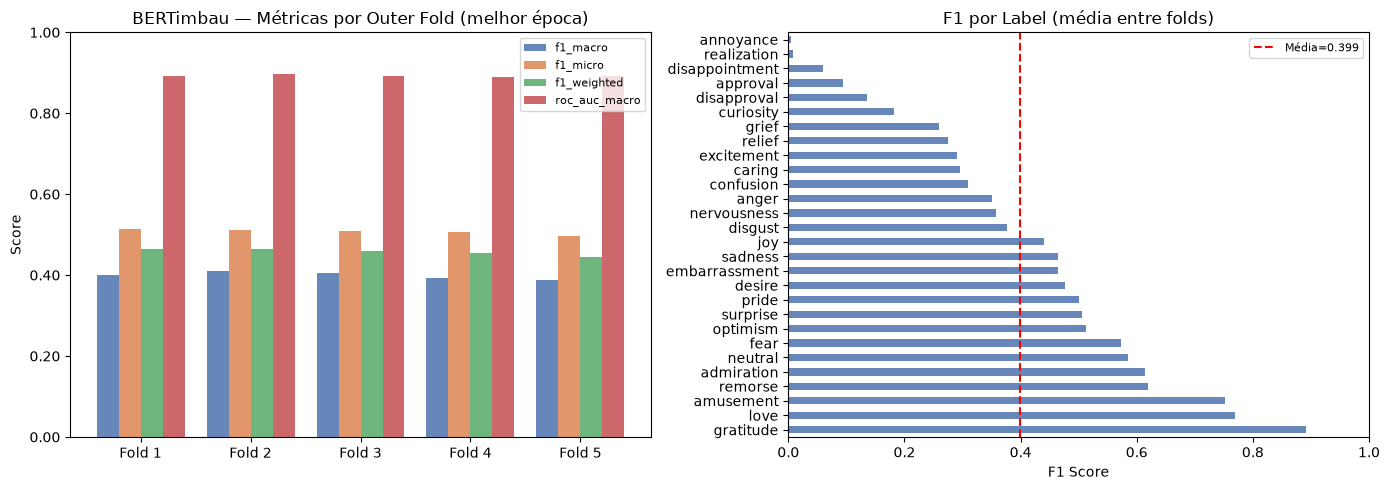

Figura salva em ..\data\out\bertimbau\bertimbau_metrics.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metric_plot = ["f1_macro", "f1_micro", "f1_weighted", "roc_auc_macro"]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

ax = axes[0]
x = np.arange(len(df_results))
width = 0.20
for i, (met, col) in enumerate(zip(metric_plot, colors)):
    ax.bar(x + i * width, df_results[met], width, label=met, color=col, alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([f"Fold {k}" for k in df_results.index])
ax.set_ylim(0, 1)
ax.set_title("BERTimbau — Métricas por Outer Fold (melhor época)")
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.set_ylabel("Score")

ax2 = axes[1]
f1_per_label_mean.plot.barh(ax=ax2, color="#4C72B0", alpha=0.85)
ax2.set_title("F1 por Label (média entre folds)")
ax2.set_xlabel("F1 Score")
ax2.set_xlim(0, 1)
ax2.axvline(
    f1_per_label_mean.mean(), color="red", linestyle="--",
    label=f"Média={f1_per_label_mean.mean():.3f}"
)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / "bertimbau_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura salva em {OUT_DIR / 'bertimbau_metrics.png'}")

In [18]:
# Métricas globais
df_results.to_csv(OUT_DIR / "bertimbau_global_metrics.csv")

# F1 por label
f1_per_label_folds.to_csv(OUT_DIR / "bertimbau_f1_per_label.csv")

# Resumo JSON
summary_dict = {
    "model": "BERTimbau-base (neuralmind/bert-base-portuguese-cased)",
    "loss": "CrossBalancedLoss (beta=0.9999)",
    "optimizer": "AdamWeightDecay (lr=2e-5, wd=0.01)",
    "scheduler": "Polynomial decay + linear warmup (10%)",
    "strategy": f"Outer CV ({N_OUTER_FOLDS} folds), {NUM_EPOCHS} épocas",
    "n_labels": N_LABELS,
    "max_len": MAX_LEN,
    "batch_size": BATCH_SIZE,
    "f1_macro_mean": round(float(df_results["f1_macro"].mean()), 4),
    "f1_macro_std": round(float(df_results["f1_macro"].std()),  4),
    "f1_micro_mean": round(float(df_results["f1_micro"].mean()), 4),
    "f1_micro_std": round(float(df_results["f1_micro"].std()),  4),
    "roc_auc_mean": round(float(df_results["roc_auc_macro"].mean()), 4),
    "roc_auc_std": round(float(df_results["roc_auc_macro"].std()),  4),
}

with open(OUT_DIR / "bertimbau_summary.json", "w") as f:
    json.dump(summary_dict, f, indent=2, ensure_ascii=False)

print("Arquivos exportados para:", OUT_DIR.resolve())
print(json.dumps(summary_dict, indent=2, ensure_ascii=False))

Arquivos exportados para: C:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\data\out\bertimbau
{
  "model": "BERTimbau-base (neuralmind/bert-base-portuguese-cased)",
  "loss": "CrossBalancedLoss (beta=0.9999)",
  "optimizer": "AdamWeightDecay (lr=2e-5, wd=0.01)",
  "scheduler": "Polynomial decay + linear warmup (10%)",
  "strategy": "Outer CV (5 folds), 4 épocas",
  "n_labels": 28,
  "max_len": 128,
  "batch_size": 32,
  "f1_macro_mean": 0.399,
  "f1_macro_std": 0.0095,
  "f1_micro_mean": 0.5069,
  "f1_micro_std": 0.0068,
  "roc_auc_mean": 0.893,
  "roc_auc_std": 0.0026
}


## Testes Limiar

In [4]:
# ══════════════════════════════════════════════════════════════════
# TESTES DE LIMIAR — baseline honesto do BERTimbau
# Não treina nada. Reaproveita as probabilidades OOF já geradas.
# ══════════════════════════════════════════════════════════════════
from sklearn.metrics import average_precision_score
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Caches de probabilidades OOF (gerados pelos notebooks do ensemble)
CACHE_V1 = Path("../data/out/ensemble_fuzzy/cache")
CACHE_V2 = Path("../data/out/ensemble_fuzzy_2/cache")

# Métricas do ensemble, para a comparação final
V1_METRICS = Path("../data/out/ensemble_fuzzy/ensemble_fuzzy_global_metrics.csv")
V2_METRICS = Path("../data/out/ensemble_fuzzy_2/ensemble_fuzzy2_global_metrics.csv")

# Saídas deste teste (separadas — não tocam em ../data/out/bertimbau)
OUT_LIMIAR = Path("../data/out/testes_limiar")
CACHE_LIMIAR = OUT_LIMIAR / "cache"
OUT_LIMIAR.mkdir(parents=True, exist_ok=True)
CACHE_LIMIAR.mkdir(parents=True, exist_ok=True)

# A MESMA grade usada em fit_fuzzy_emotion → comparação apples-to-apples
THRESH_GRID = np.linspace(0.05, 0.95, 19)
# Grade fina: só teste de robustez, NÃO é a comparação justa
THRESH_GRID_FINE = np.linspace(0.01, 0.99, 197)

FIXED_THRESHOLD = 0.5   # o que os baselines usam hoje

def load_fold(fold_id: int):
    fold_dir = DATA_DIR / f"fold_{fold_id}"
    df  = pd.read_parquet(fold_dir / "data.parquet")
    idx = np.load(fold_dir / "idx.npy")
    return df, idx

folds_data = {}
for k in range(1, N_OUTER_FOLDS + 1):
    df_k, idx_k = load_fold(k)
    folds_data[k] = {"df": df_k, "idx": idx_k}
    print(f"Fold {k}: {df_k.shape[0]:>6} amostras")

def prepare_Y(df):
    present = [c for c in EMOTION_COLS if c in df.columns]
    assert len(present) == N_LABELS, f"Faltam labels: {set(EMOTION_COLS) - set(present)}"
    return df[present].values.astype(int)

Y_folds    = {k: prepare_Y(folds_data[k]["df"]) for k in folds_data}
TEXT_folds = {k: folds_data[k]["df"][TEXT_COL].fillna("").astype(str).values for k in folds_data}

Y_all = np.vstack([Y_folds[k] for k in folds_data])
base_rates = pd.Series(Y_all.mean(axis=0), index=EMOTION_COLS)

print(f"\nBase rate — mediana: {base_rates.median():.4f} | "
      f"min: {base_rates.min():.4f} ({base_rates.idxmin()}) | "
      f"max: {base_rates.max():.4f} ({base_rates.idxmax()})")
print("Compare com o limiar 0.5 usado no baseline.")

Fold 1:  10831 amostras
Fold 2:  10810 amostras
Fold 3:  10836 amostras
Fold 4:  10909 amostras
Fold 5:  10848 amostras

Base rate — mediana: 0.0296 | min: 0.0018 (grief) | max: 0.3273 (neutral)
Compare com o limiar 0.5 usado no baseline.


In [5]:
def find_cached(fname):
    for d in (CACHE_V1, CACHE_V2, CACHE_LIMIAR):
        fp = d / fname
        if fp.exists():
            return fp
    return None

def best_epoch_per_fold():
    fp = OUT_DIR / "bertimbau_global_metrics.csv"   # OUT_DIR = ../data/out/bertimbau
    if fp.exists():
        df = pd.read_csv(fp, index_col=0)
        if "epoch" in df.columns:
            return {int(f): int(e) for f, e in df["epoch"].items()}
    return None

def compute_bert_oof(missing_folds):
    """Regenera P_BERT a partir dos checkpoints (só se não houver cache)."""
    import numpy.dtypes
    torch.serialization.add_safe_globals([numpy.dtypes.Float64DType])

    _tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    _BATCH = 64

    class _BERTimbauForEmotions(nn.Module):
        # nomes de atributos idênticos ao baseline (compatibilidade com o state_dict)
        def __init__(self, model_name=MODEL_NAME, n_labels=N_LABELS, dropout=0.1):
            super().__init__()
            self.bert = AutoModel.from_pretrained(model_name)
            self.dropout = nn.Dropout(dropout)
            self.classifier = nn.Linear(self.bert.config.hidden_size, n_labels)
        def forward(self, input_ids, attention_mask):
            out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
            return self.classifier(self.dropout(out.last_hidden_state[:, 0, :]))

    best_eps = best_epoch_per_fold()

    def find_ckpt(fold):
        if best_eps and fold in best_eps:
            fp = CKPT_DIR / f"fold_{fold}_epoch_{best_eps[fold]:02d}.pt"
            if fp.exists():
                return fp
        cands = sorted(CKPT_DIR.glob(f"fold_{fold}_epoch_*.pt"))
        assert cands, f"Nenhum checkpoint para o fold {fold} em {CKPT_DIR}"
        best_fp, best_f1 = None, -1
        for fp in cands:
            ck = torch.load(fp, map_location="cpu", weights_only=False)
            f1 = ck.get("metrics", {}).get("f1_macro", -1)
            if f1 > best_f1:
                best_fp, best_f1 = fp, f1
            del ck
        return best_fp

    for k in missing_folds:
        t0 = time.time()
        ckpt_path = find_ckpt(k)
        print(f"  Fold {k}: {ckpt_path.name}")
        ck = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        model = _BERTimbauForEmotions().to(DEVICE)
        model.load_state_dict(ck["model_state_dict"])
        model.eval()

        texts, probas = TEXT_folds[k].tolist(), []
        with torch.no_grad():
            for i in range(0, len(texts), _BATCH):
                enc = _tokenizer(texts[i:i + _BATCH], max_length=MAX_LEN,
                                 padding="max_length", truncation=True, return_tensors="pt")
                logits = model(enc["input_ids"].to(DEVICE), enc["attention_mask"].to(DEVICE))
                probas.append(torch.sigmoid(logits).cpu().numpy())
        np.save(CACHE_LIMIAR / f"P_BERT_fold_{k}.npy", np.vstack(probas))
        del model, ck
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()
        print(f"  P_BERT fold {k} salvo ({time.time() - t0:.0f}s)")


missing = [k for k in folds_data if find_cached(f"P_BERT_fold_{k}.npy") is None]
if missing:
    print(f"Cache ausente → gerando P_BERT para os folds {missing}...")
    compute_bert_oof(missing)
else:
    print("P_BERT encontrado em cache — nada será recalculado.")

P_BERT_folds = {k: np.load(find_cached(f"P_BERT_fold_{k}.npy")) for k in folds_data}
print("P_BERT OK:", {k: v.shape for k, v in P_BERT_folds.items()})

# P_LR é opcional: só entra se já estiver em cache (não retreinamos LR aqui)
P_LR_folds = None
if all(find_cached(f"P_LR_fold_{k}.npy") is not None for k in folds_data):
    P_LR_folds = {k: np.load(find_cached(f"P_LR_fold_{k}.npy")) for k in folds_data}
    print("P_LR  OK:", {k: v.shape for k, v in P_LR_folds.items()})
else:
    print("P_LR não encontrado em cache → o LR fica fora desta análise.")

P_BERT encontrado em cache — nada será recalculado.
P_BERT OK: {1: (10831, 28), 2: (10810, 28), 3: (10836, 28), 4: (10909, 28), 5: (10848, 28)}
P_LR  OK: {1: (10831, 28), 2: (10810, 28), 3: (10836, 28), 4: (10909, 28), 5: (10848, 28)}


In [6]:
def calibrate_thresholds(P_cal, Y_cal, grid):
    """Por emoção, o limiar da grade que maximiza F1 no conjunto de CALIBRAÇÃO.
    Mesma lógica de fit_fuzzy_emotion (vetorizada)."""
    thr = np.full(N_LABELS, 0.5)
    f1s = np.zeros(N_LABELS)
    for j in range(N_LABELS):
        y = Y_cal[:, j]
        if y.sum() == 0:
            continue
        pred = P_cal[:, j][:, None] >= grid[None, :]     # (n, G)
        yb   = (y == 1)[:, None]
        tp = (pred & yb).sum(0)
        fp = (pred & ~yb).sum(0)
        fn = (~pred & yb).sum(0)
        f1 = 2 * tp / np.maximum(2 * tp + fp + fn, 1e-12)
        b = int(np.argmax(f1))
        thr[j], f1s[j] = float(grid[b]), float(f1[b])
    return thr, f1s


def metrics_limiar(Y_true, Y_pred, Y_score, label_names):
    """Mesmas métricas do baseline + Average Precision (PR-AUC)."""
    m = {
        "accuracy"       : accuracy_score(Y_true, Y_pred),
        "hamming_loss"   : hamming_loss(Y_true, Y_pred),
        "f1_macro"       : f1_score(Y_true, Y_pred, average="macro",    zero_division=0),
        "f1_micro"       : f1_score(Y_true, Y_pred, average="micro",    zero_division=0),
        "f1_weighted"    : f1_score(Y_true, Y_pred, average="weighted", zero_division=0),
        "precision_macro": precision_score(Y_true, Y_pred, average="macro", zero_division=0),
        "recall_macro"   : recall_score(Y_true, Y_pred, average="macro",    zero_division=0),
    }
    valid = [j for j in range(Y_true.shape[1]) if Y_true[:, j].sum() > 0]
    if valid:
        m["roc_auc_macro"] = roc_auc_score(Y_true[:, valid], Y_score[:, valid], average="macro")
        # PR-AUC: métrica de ranking apropriada sob desbalanceamento
        m["avg_precision_macro"] = average_precision_score(
            Y_true[:, valid], Y_score[:, valid], average="macro")
    else:
        m["roc_auc_macro"] = m["avg_precision_macro"] = float("nan")
    m["f1_per_label"] = dict(zip(label_names,
                                 f1_score(Y_true, Y_pred, average=None, zero_division=0)))
    return m

print("Funções prontas.")

Funções prontas.


In [7]:
results      = {}
results_fine = {}
thr_store    = {}

sources = {"BERT": P_BERT_folds}
if P_LR_folds is not None:
    sources["LR"] = P_LR_folds

for name in sources:
    results[f"{name}@0.5"] = []
    results[f"{name}@tuned"] = []
    results_fine[f"{name}@tuned_fine"] = []

for outer_k in range(1, N_OUTER_FOLDS + 1):
    print(f"\n{'='*62}\n  OUTER FOLD {outer_k}/{N_OUTER_FOLDS}\n{'='*62}")
    train_ks = [j for j in folds_data if j != outer_k]

    Y_cal = np.vstack([Y_folds[j] for j in train_ks])
    Y_te  = Y_folds[outer_k]
    print(f"  Calibração: {len(Y_cal):>6} | Teste: {len(Y_te):>5}")

    thr_store[outer_k] = {}
    for name, P_folds in sources.items():
        P_cal = np.vstack([P_folds[j] for j in train_ks])   # OOF: nenhum modelo viu esses dados
        P_te  = P_folds[outer_k]

        # (a) limiar fixo 0.5 — o que o baseline reporta hoje
        m_fix = metrics_limiar(Y_te, (P_te >= FIXED_THRESHOLD).astype(int), P_te, EMOTION_COLS)
        m_fix["outer_fold"] = outer_k
        results[f"{name}@0.5"].append(m_fix)

        # (b) limiar calibrado por emoção — MESMA grade do Ensemble Fuzzy
        thr, _ = calibrate_thresholds(P_cal, Y_cal, THRESH_GRID)
        m_tun = metrics_limiar(Y_te, (P_te >= thr[None, :]).astype(int), P_te, EMOTION_COLS)
        m_tun["outer_fold"] = outer_k
        results[f"{name}@tuned"].append(m_tun)
        thr_store[outer_k][name] = thr

        # (c) grade fina — robustez, NÃO é a comparação justa
        thr_f, _ = calibrate_thresholds(P_cal, Y_cal, THRESH_GRID_FINE)
        m_fine = metrics_limiar(Y_te, (P_te >= thr_f[None, :]).astype(int), P_te, EMOTION_COLS)
        m_fine["outer_fold"] = outer_k
        results_fine[f"{name}@tuned_fine"].append(m_fine)

        print(f"  {name:4s} @0.5       | F1={m_fix['f1_macro']:.4f} P={m_fix['precision_macro']:.4f} "
              f"R={m_fix['recall_macro']:.4f} AP={m_fix['avg_precision_macro']:.4f}")
        print(f"  {name:4s} @calibrado | F1={m_tun['f1_macro']:.4f} P={m_tun['precision_macro']:.4f} "
              f"R={m_tun['recall_macro']:.4f} AP={m_tun['avg_precision_macro']:.4f} "
              f"(limiar médio={thr.mean():.2f})")

print("\n✓ Concluído.")


  OUTER FOLD 1/5
  Calibração:  43403 | Teste: 10831
  BERT @0.5       | F1=0.3999 P=0.6283 R=0.3417 AP=0.4330
  BERT @calibrado | F1=0.4692 P=0.4766 R=0.4878 AP=0.4330 (limiar médio=0.28)
  LR   @0.5       | F1=0.3695 P=0.3324 R=0.4560 AP=0.3390
  LR   @calibrado | F1=0.3790 P=0.3851 R=0.4025 AP=0.3390 (limiar médio=0.66)

  OUTER FOLD 2/5
  Calibração:  43424 | Teste: 10810
  BERT @0.5       | F1=0.4110 P=0.6144 R=0.3439 AP=0.4521
  BERT @calibrado | F1=0.4806 P=0.4764 R=0.4994 AP=0.4521 (limiar médio=0.26)
  LR   @0.5       | F1=0.3608 P=0.3172 R=0.4587 AP=0.3260
  LR   @calibrado | F1=0.3703 P=0.3660 R=0.3973 AP=0.3260 (limiar médio=0.66)

  OUTER FOLD 3/5
  Calibração:  43398 | Teste: 10836
  BERT @0.5       | F1=0.4044 P=0.6053 R=0.3500 AP=0.4345
  BERT @calibrado | F1=0.4697 P=0.4602 R=0.4947 AP=0.4345 (limiar médio=0.26)
  LR   @0.5       | F1=0.3663 P=0.3249 R=0.4729 AP=0.3487
  LR   @calibrado | F1=0.3830 P=0.3766 R=0.4315 AP=0.3487 (limiar médio=0.64)

  OUTER FOLD 4/5
  Ca

In [8]:
def folds_df(metric_list):
    keys = ["accuracy", "precision_macro", "recall_macro", "f1_macro",
            "f1_micro", "roc_auc_macro", "avg_precision_macro"]
    return pd.DataFrame([{k: m[k] for k in keys} for m in metric_list],
                        index=[m["outer_fold"] for m in metric_list])

dfs      = {name: folds_df(v) for name, v in results.items()}
dfs_fine = {name: folds_df(v) for name, v in results_fine.items()}

rows = []
for name, d in dfs.items():
    r = {"Configuração": name}
    for c in ["accuracy", "precision_macro", "recall_macro", "f1_macro",
              "f1_micro", "roc_auc_macro", "avg_precision_macro"]:
        r[c] = f"{d[c].mean():.4f} ± {d[c].std():.4f}"
    rows.append(r)
df_thresh = pd.DataFrame(rows).set_index("Configuração")

print("===== EFEITO DO LIMIAR (mesmo modelo, mesmas probabilidades) =====")
display(df_thresh)

for name in sources:
    d0, d1 = dfs[f"{name}@0.5"], dfs[f"{name}@tuned"]
    delta = d1["f1_macro"].mean() - d0["f1_macro"].mean()
    print(f"\n{name}: F1-macro {d0['f1_macro'].mean():.4f} → {d1['f1_macro'].mean():.4f} "
          f"({delta:+.4f}) — apenas calibrando o limiar")
    try:
        s, p = wilcoxon(d1["f1_macro"].values, d0["f1_macro"].values)
        print(f"     Wilcoxon pareado (n=5 folds): W={s:.1f}, p={p:.4f}")
    except ValueError as e:
        print(f"     Wilcoxon não aplicável: {e}")

print("\n===== ROBUSTEZ: grade fina (NÃO é a comparação justa) =====")
display(pd.DataFrame([
    {"Configuração": name,
     **{c: f"{d[c].mean():.4f} ± {d[c].std():.4f}"
        for c in ["precision_macro", "recall_macro", "f1_macro", "f1_micro"]}}
    for name, d in dfs_fine.items()
]).set_index("Configuração"))

===== EFEITO DO LIMIAR (mesmo modelo, mesmas probabilidades) =====


,accuracy,precision_macro,recall_macro,f1_macro,f1_micro,roc_auc_macro,avg_precision_macro
Configuração,,,,,,,
BERT@0.5,0.3827 ± 0.0067,0.6072 ± 0.0212,0.3415 ± 0.0066,0.3990 ± 0.0095,0.5069 ± 0.0068,0.8930 ± 0.0026,0.4353 ± 0.0100
BERT@tuned,0.3457 ± 0.0080,0.4720 ± 0.0078,0.4864 ± 0.0130,0.4688 ± 0.0090,0.5415 ± 0.0053,0.8930 ± 0.0026,0.4353 ± 0.0100
LR@0.5,0.1873 ± 0.0088,0.3240 ± 0.0088,0.4652 ± 0.0075,0.3655 ± 0.0052,0.4152 ± 0.0054,0.8390 ± 0.0017,0.3362 ± 0.0092
LR@tuned,0.2422 ± 0.0071,0.3747 ± 0.0131,0.4119 ± 0.0136,0.3784 ± 0.0050,0.4690 ± 0.0020,0.8390 ± 0.0017,0.3362 ± 0.0092



BERT: F1-macro 0.3990 → 0.4688 (+0.0698) — apenas calibrando o limiar
     Wilcoxon pareado (n=5 folds): W=0.0, p=0.0625

LR: F1-macro 0.3655 → 0.3784 (+0.0129) — apenas calibrando o limiar
     Wilcoxon pareado (n=5 folds): W=0.0, p=0.0625

===== ROBUSTEZ: grade fina (NÃO é a comparação justa) =====


,precision_macro,recall_macro,f1_macro,f1_micro
Configuração,,,,
BERT@tuned_fine,0.4703 ± 0.0049,0.4867 ± 0.0091,0.4689 ± 0.0086,0.5438 ± 0.0059
LR@tuned_fine,0.3739 ± 0.0118,0.4097 ± 0.0115,0.3777 ± 0.0039,0.4702 ± 0.0023


In [9]:
comp, fuzzy_f1 = [], {}

for name, d in dfs.items():
    comp.append({
        "Modelo": name,
        "precision_macro": d["precision_macro"].mean(),
        "recall_macro"   : d["recall_macro"].mean(),
        "f1_macro"       : d["f1_macro"].mean(),
        "f1_macro_std"   : d["f1_macro"].std(),
        "f1_micro"       : d["f1_micro"].mean(),
        "roc_auc_macro"  : d["roc_auc_macro"].mean(),
    })

for label, fp in [("Ensemble Fuzzy v1", V1_METRICS), ("Ensemble Fuzzy v2", V2_METRICS)]:
    if fp.exists():
        d = pd.read_csv(fp, index_col=0)
        comp.append({
            "Modelo": label,
            "precision_macro": d["precision_macro"].mean(),
            "recall_macro"   : d["recall_macro"].mean(),
            "f1_macro"       : d["f1_macro"].mean(),
            "f1_macro_std"   : d["f1_macro"].std(),
            "f1_micro"       : d["f1_micro"].mean(),
            "roc_auc_macro"  : d["roc_auc_macro"].mean(),
        })
        fuzzy_f1[label] = d["f1_macro"].values
    else:
        print(f"(aviso) {fp} não encontrado — {label} fora da comparação.")

df_final = pd.DataFrame(comp).set_index("Modelo").sort_values("f1_macro", ascending=False)
print("===== COMPARAÇÃO FINAL — todos com tratamento de limiar equivalente =====")
display(df_final.round(4))
print(f"\nMelhor F1-macro: {df_final.index[0]} ({df_final['f1_macro'].iloc[0]:.4f})")

# Teste decisivo: Fuzzy v2 vs BERT@calibrado
if "Ensemble Fuzzy v2" in fuzzy_f1:
    a = fuzzy_f1["Ensemble Fuzzy v2"]
    b = dfs["BERT@tuned"]["f1_macro"].values
    print(f"\n----- Fuzzy v2 vs BERT@calibrado (F1-macro por fold) -----")
    print(f"  Fuzzy v2       : {a.mean():.4f} ± {a.std():.4f}")
    print(f"  BERT@calibrado : {b.mean():.4f} ± {b.std():.4f}")
    print(f"  Δ (fuzzy − bert): {a.mean() - b.mean():+.4f}")
    try:
        s, p = wilcoxon(a, b)
        print(f"  Wilcoxon: W={s:.1f}, p={p:.4f}")
    except ValueError as e:
        print(f"  Wilcoxon não aplicável: {e}")
    print("\n  →", "O ensemble AINDA supera o baseline honesto → o fuzzy agrega valor real."
          if a.mean() > b.mean() else
          "O baseline honesto SUPERA o ensemble → o ganho anterior era efeito de limiar.")

===== COMPARAÇÃO FINAL — todos com tratamento de limiar equivalente =====


,precision_macro,recall_macro,f1_macro,f1_macro_std,f1_micro,roc_auc_macro
Modelo,,,,,,
BERT@tuned,0.4720,0.4864,0.4688,0.0090,0.5415,0.8930
Ensemble Fuzzy v2,0.3724,0.5157,0.4139,0.0049,0.4834,0.8356
Ensemble Fuzzy v1,0.3465,0.5495,0.4008,0.0051,0.4457,0.8521
BERT@0.5,0.6072,0.3415,0.3990,0.0095,0.5069,0.8930
LR@tuned,0.3747,0.4119,0.3784,0.0050,0.4690,0.8390
LR@0.5,0.3240,0.4652,0.3655,0.0052,0.4152,0.8390



Melhor F1-macro: BERT@tuned (0.4688)

----- Fuzzy v2 vs BERT@calibrado (F1-macro por fold) -----
  Fuzzy v2       : 0.4139 ± 0.0044
  BERT@calibrado : 0.4688 ± 0.0080
  Δ (fuzzy − bert): -0.0548
  Wilcoxon: W=0.0, p=0.0625

  → O baseline honesto SUPERA o ensemble → o ganho anterior era efeito de limiar.


===== LIMIAR CALIBRADO POR EMOÇÃO (BERTimbau, média entre folds) =====


,limiar_calibrado,base_rate
grief,0.38,0.0018
pride,0.45,0.0026
relief,0.40,0.0034
nervousness,0.36,0.0038
embarrassment,0.50,0.0069
remorse,0.20,0.0123
fear,0.39,0.0141
desire,0.27,0.0148
disgust,0.32,0.0187
excitement,0.20,0.0194



Limiar médio calibrado: 0.276 (vs 0.5 no baseline)
Emoções com limiar ótimo < 0.5: 28/28


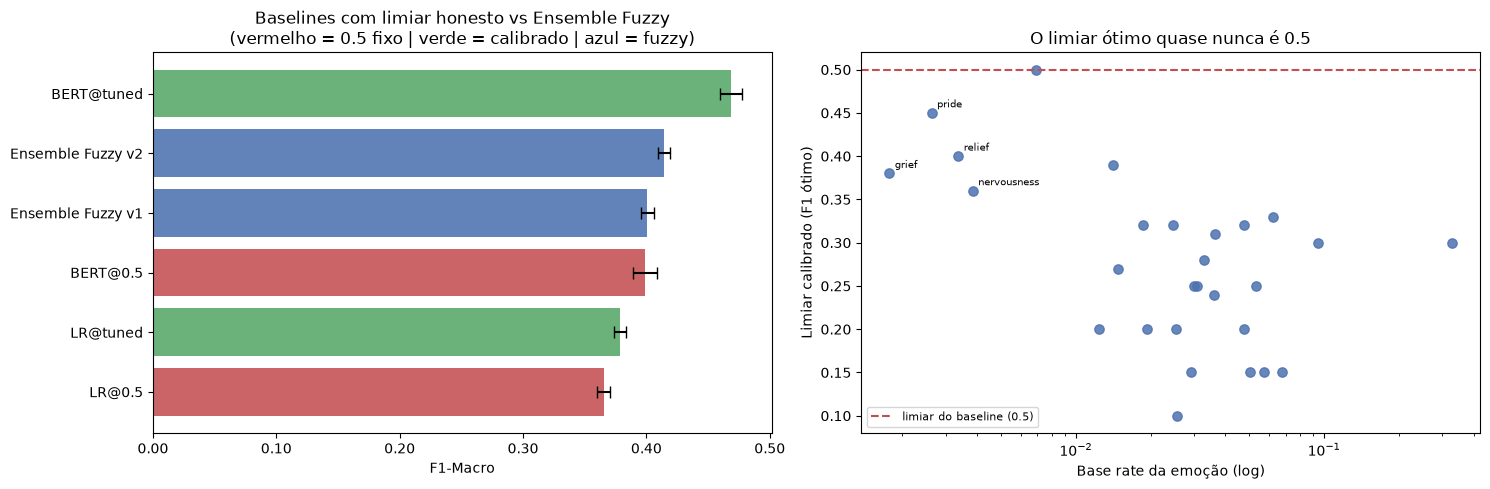

In [10]:
thr_mean = pd.DataFrame(
    {f"fold_{k}": thr_store[k]["BERT"] for k in thr_store}, index=EMOTION_COLS
).mean(axis=1)

df_thr = pd.DataFrame({
    "limiar_calibrado": thr_mean,
    "base_rate": base_rates.reindex(EMOTION_COLS),
}).sort_values("base_rate")

print("===== LIMIAR CALIBRADO POR EMOÇÃO (BERTimbau, média entre folds) =====")
display(df_thr.round(4))
print(f"\nLimiar médio calibrado: {thr_mean.mean():.3f} (vs 0.5 no baseline)")
print(f"Emoções com limiar ótimo < 0.5: {int((thr_mean < 0.5).sum())}/{N_LABELS}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
order = df_final.sort_values("f1_macro")
cols = ["#C44E52" if "@0.5" in i else ("#4C72B0" if "Fuzzy" in i else "#55A868")
        for i in order.index]
ax.barh(order.index, order["f1_macro"], xerr=order["f1_macro_std"],
        capsize=4, color=cols, alpha=0.88)
ax.set_xlabel("F1-Macro")
ax.set_title("Baselines com limiar honesto vs Ensemble Fuzzy\n"
             "(vermelho = 0.5 fixo | verde = calibrado | azul = fuzzy)")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

ax2 = axes[1]
ax2.scatter(df_thr["base_rate"], df_thr["limiar_calibrado"], s=45, color="#4C72B0", alpha=0.85)
ax2.axhline(0.5, color="#C44E52", linestyle="--", label="limiar do baseline (0.5)")
ax2.set_xscale("log")
ax2.set_xlabel("Base rate da emoção (log)")
ax2.set_ylabel("Limiar calibrado (F1 ótimo)")
ax2.set_title("O limiar ótimo quase nunca é 0.5")
ax2.legend(fontsize=8)
for emo in df_thr.index[:4]:
    ax2.annotate(emo, (df_thr.loc[emo, "base_rate"], df_thr.loc[emo, "limiar_calibrado"]),
                 fontsize=7, xytext=(4, 4), textcoords="offset points")

plt.tight_layout()
plt.savefig(OUT_LIMIAR / "testes_limiar_bert.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
df_thresh.to_csv(OUT_LIMIAR / "efeito_limiar.csv")
df_final.to_csv(OUT_LIMIAR / "comparacao_final_limiar_honesto.csv")
df_thr.to_csv(OUT_LIMIAR / "limiares_calibrados_por_emocao.csv")
pd.DataFrame({name: pd.DataFrame([m["f1_per_label"] for m in v]).mean()
              for name, v in results.items()}).to_csv(OUT_LIMIAR / "f1_por_label_limiar.csv")
np.save(CACHE_LIMIAR / "thresholds_bert.npy",
        np.vstack([thr_store[k]["BERT"] for k in sorted(thr_store)]))

summary = {
    "objetivo": ("Medir o BERTimbau com o MESMO tratamento de limiar que o Ensemble Fuzzy "
                 "recebe (calibrado por emocao, OOF), em vez de 0.5 fixo."),
    "protocolo": ("Para cada outer fold k: limiares calibrados por emocao nas probabilidades "
                  "OOF dos folds j!=k (grade identica a THRESH_GRID do fuzzy), aplicados em "
                  "P_BERT[k]. Nenhum limiar escolhido no fold de teste."),
    "grade_justa": [float(THRESH_GRID.min()), float(THRESH_GRID.max()), int(len(THRESH_GRID))],
    "nota_metrica": ("ROC-AUC e otimista sob desbalanceamento; Average Precision (PR-AUC) e "
                     "a metrica de ranking apropriada para labels raros."),
    "ressalva": ("P_BERT herda do baseline a selecao da melhor epoca pelo F1 no proprio fold "
                 "de teste; como o Ensemble Fuzzy usa o mesmo P_BERT, a comparacao relativa "
                 "nao e afetada, mas o valor absoluto e levemente otimista."),
    "resultados": {name: {
        "f1_macro": f"{d['f1_macro'].mean():.4f} +/- {d['f1_macro'].std():.4f}",
        "precision_macro": f"{d['precision_macro'].mean():.4f}",
        "recall_macro": f"{d['recall_macro'].mean():.4f}",
        "avg_precision_macro": f"{d['avg_precision_macro'].mean():.4f}",
        "roc_auc_macro": f"{d['roc_auc_macro'].mean():.4f}",
    } for name, d in dfs.items()},
    "limiar_medio_bert": float(thr_mean.mean()),
    "n_emocoes_limiar_abaixo_0.5": int((thr_mean < 0.5).sum()),
}
with open(OUT_LIMIAR / "testes_limiar_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("Arquivos exportados para", OUT_LIMIAR.resolve())
print(json.dumps(summary, indent=2, ensure_ascii=False))

Arquivos exportados para C:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\data\out\testes_limiar
{
  "objetivo": "Medir o BERTimbau com o MESMO tratamento de limiar que o Ensemble Fuzzy recebe (calibrado por emocao, OOF), em vez de 0.5 fixo.",
  "protocolo": "Para cada outer fold k: limiares calibrados por emocao nas probabilidades OOF dos folds j!=k (grade identica a THRESH_GRID do fuzzy), aplicados em P_BERT[k]. Nenhum limiar escolhido no fold de teste.",
  "grade_justa": [
    0.05,
    0.95,
    19
  ],
  "nota_metrica": "ROC-AUC e otimista sob desbalanceamento; Average Precision (PR-AUC) e a metrica de ranking apropriada para labels raros.",
  "ressalva": "P_BERT herda do baseline a selecao da melhor epoca pelo F1 no proprio fold de teste; como o Ensemble Fuzzy usa o mesmo P_BERT, a comparacao relativa nao e afetada, mas o valor absoluto e levemente otimista.",
  "resultados": {
    "BERT@0.5": {
      "f1_macro": "0.3990 +/- 0.0095",
      "precisi